In [22]:
import pandas as pd
import numpy as np

# Load Users dataset
users = pd.read_csv("data/EduPro Online Platform.xlsx - Users (1).csv")

# Show first 5 rows
users.head()

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [23]:
# Number of rows and columns
print(users.shape)

# Column names and data types
print(users.info())

(3000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB
None


In [24]:
users.isnull().sum()

UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

In [25]:
users.duplicated().sum()

np.int64(0)

In [26]:
users.describe()

,Age
count,3000.000000
mean,24.974333
std,6.046475
min,15.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,35.000000


In [27]:
users.columns

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')

In [28]:
users.head()
users.shape
users.info()
users.isnull().sum()
users.duplicated().sum()
users.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


,Age
count,3000.000000
mean,24.974333
std,6.046475
min,15.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,35.000000


Total Students

In [29]:
print("Total Students:", users.shape[0])

Total Students: 3000


Age Distribution

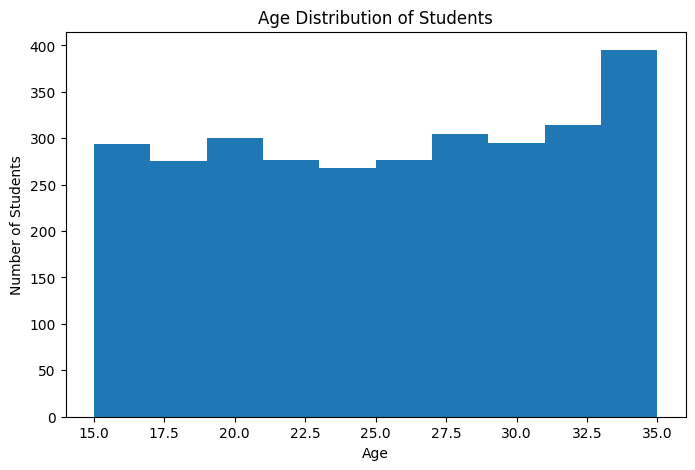

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(users["Age"], bins=10)

plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

Gender Distributionx

In [31]:
users["Gender"].value_counts()


Gender
Female    1520
Male      1480
Name: count, dtype: int64

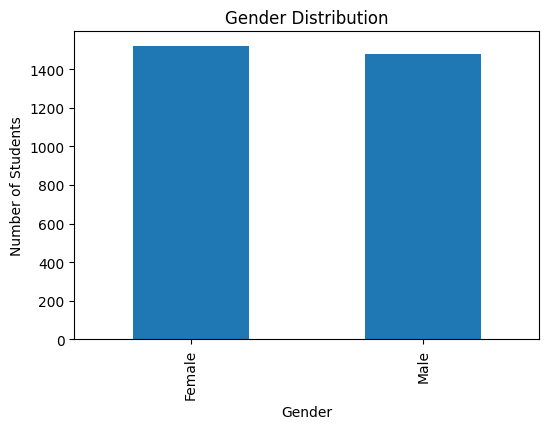

In [32]:
users["Gender"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

In [33]:
(users["Gender"].value_counts(normalize=True) * 100).round(2)

Gender
Female    50.67
Male      49.33
Name: proportion, dtype: float64

In [34]:
print("Minimum Age :", users["Age"].min())
print("Maximum Age :", users["Age"].max())
print("Average Age :", round(users["Age"].mean(),2))
print("Median Age  :", users["Age"].median())

Minimum Age : 15
Maximum Age : 35
Average Age : 24.97
Median Age  : 25.0


In [35]:
# Create Age Groups
users["AgeGroup"] = pd.cut(
    users["Age"],
    bins=[14, 20, 30, 40, 50, 60],
    labels=["15-20", "21-30", "31-40", "41-50", "51-60"]
)

users.head()

,UserID,UserName,Age,Gender,Email,AgeGroup
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-20
1,U00002,angela22,29,Female,hallrandy@hotmail.com,21-30
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,31-40
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,21-30
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,21-30


In [36]:
#Count Students in Each Age Group
# Count Students in Each Age Group
users["AgeGroup"].value_counts().sort_index()

AgeGroup
15-20     869
21-30    1422
31-40     709
41-50       0
51-60       0
Name: count, dtype: int64

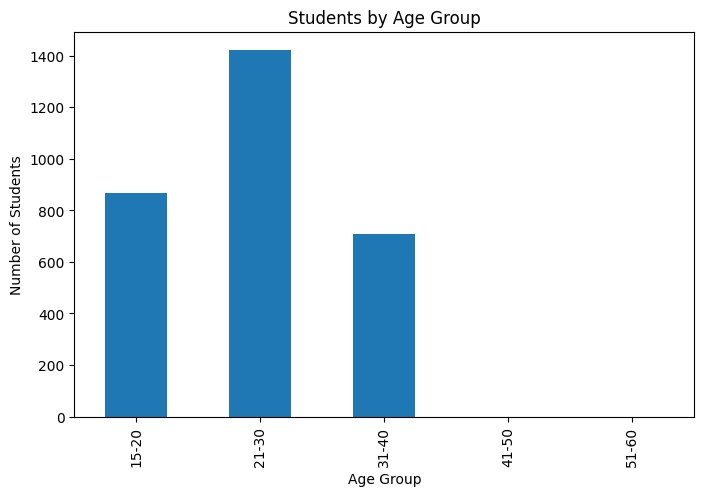

In [37]:
#Visualize Age Groups
import matplotlib.pyplot as plt

users["AgeGroup"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Students by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Students")
plt.show()

In [38]:
#Visualize Age Groups   
users["GenderEncoded"] = users["Gender"].map({
    "Male": 0,
    "Female": 1
})

users.head()

,UserID,UserName,Age,Gender,Email,AgeGroup,GenderEncoded
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-20,0
1,U00002,angela22,29,Female,hallrandy@hotmail.com,21-30,1
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,31-40,1
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,21-30,1
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,21-30,0


Create Student Profile DataFrame

In [39]:
# Create Student Profile
student_profile = users.copy()

student_profile.head()

,UserID,UserName,Age,Gender,Email,AgeGroup,GenderEncoded
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-20,0
1,U00002,angela22,29,Female,hallrandy@hotmail.com,21-30,1
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,31-40,1
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,21-30,1
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,21-30,0


In [40]:
student_profile = student_profile[
    ["UserID", "Age", "AgeGroup", "Gender", "GenderEncoded"]
]

student_profile.head()

,UserID,Age,AgeGroup,Gender,GenderEncoded
0,U00001,15,15-20,Male,0
1,U00002,29,21-30,Female,1
2,U00003,33,31-40,Female,1
3,U00004,23,21-30,Female,1
4,U00005,21,21-30,Male,0


In [41]:
#Save Student Profile
student_profile.to_csv(
    "data/student_profile.csv",
    index=False
)


print("Student Profile Saved Successfully!")

Student Profile Saved Successfully!


In [42]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [43]:
# Create Label Encoder object
label_encoder = LabelEncoder()

In [44]:
student_profile["AgeGroupEncoded"] = label_encoder.fit_transform(
    student_profile["AgeGroup"]
)

student_profile.head()

,UserID,Age,AgeGroup,Gender,GenderEncoded,AgeGroupEncoded
0,U00001,15,15-20,Male,0,0
1,U00002,29,21-30,Female,1,1
2,U00003,33,31-40,Female,1,2
3,U00004,23,21-30,Female,1,1
4,U00005,21,21-30,Male,0,1


In [45]:
# Select only numerical features for ML
ml_features = student_profile[
    ["Age", "GenderEncoded", "AgeGroupEncoded"]
]

ml_features.head()

,Age,GenderEncoded,AgeGroupEncoded
0,15,0,0
1,29,1,1
2,33,1,2
3,23,1,1
4,21,0,1


In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
# Create scaler object
scaler = StandardScaler()